In [432]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt
from scipy import stats

<b>First</b> I want to bring in my dataset to start playing with the data

In [194]:
df = pd.read_csv('data-2026-04.csv', names=['siteid', 'direction', 'type', 'start', 'end', 'count'])

In [195]:
sites = pd.read_csv('sites.csv', names=['siteid', 'site_nr', 'longitude', 'latitude', 'name', 'region', 'direction_number', 'district', 'municipality', 'interval', 'date'])

In [196]:
df.head(10)

,siteid,direction,type,start,end,count
0,1,IN,FIETSERS,2026-04-01 00:00:00.0,2026-04-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2026-04-01 00:15:00.0,2026-04-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2026-04-01 00:30:00.0,2026-04-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2026-04-01 00:45:00.0,2026-04-01 01:00:00.0,1.0
4,1,IN,FIETSERS,2026-04-01 01:00:00.0,2026-04-01 01:15:00.0,0.0
5,1,IN,FIETSERS,2026-04-01 01:15:00.0,2026-04-01 01:30:00.0,0.0
6,1,IN,FIETSERS,2026-04-01 01:30:00.0,2026-04-01 01:45:00.0,0.0
7,1,IN,FIETSERS,2026-04-01 01:45:00.0,2026-04-01 02:00:00.0,0.0
8,1,IN,FIETSERS,2026-04-01 02:00:00.0,2026-04-01 02:15:00.0,0.0
9,1,IN,FIETSERS,2026-04-01 02:15:00.0,2026-04-01 02:30:00.0,0.0


Will want to group sites into a smaller classification so they can be clustered. Maybe group by hour by splitting the start and end times into the hours?

In [197]:
#break the start and end into its component parts
#takes about 4 mins 21 secs to run
df['start_date'] = 'NULL'
df['start_time'] = 0
df['end_date'] = 'NULL'
df['end_time'] = 0




for index, val in df.iterrows():
    df.loc[index, 'start_date'] = df.loc[index, 'start'][:10]
    df.loc[index, 'start_date'] = df.loc[index, 'start_date'][:10]
    
    df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
    df.loc[index, 'start_time'] = df.loc[index, 'start_time'][:]

    df.loc[index, 'end_date'] = df.loc[index, 'end'][:10]
    df.loc[index, 'end_date'] = df.loc[index, 'end_date'][:10]

    df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]
    df.loc[index, 'end_time'] = df.loc[index, 'end_time'][:]





/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:00:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:15:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]


Next I want to add some features to better map the space I can work with.

In [198]:
for index, val in df.iterrows():
    df.loc[index, 'hour'] = pd.to_numeric(df.loc[index, 'start_time'][:2])

In [199]:
#this works
df['hour_count'] = df.groupby(['siteid', 'start_date', 'hour', 'direction'])['count'].cumsum()

In [200]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'direction'] == 'IN':
        insert_val = 1
    df.loc[index, 'direction_binary'] = insert_val

In [202]:
for index, val in df.iterrows():
    df.loc[index, 'day'] = pd.to_numeric(df.loc[index, 'start_date'][-2:])

In [228]:
#df1[df1.isna()]
# Source - https://stackoverflow.com/a/37755016
# Posted by michael_j_ward
# Retrieved 2026-05-20, License - CC BY-SA 3.0

#np.argwhere(np.isnan(df1))


df.loc[:, ['hour_count']] = df.loc[:, ['hour_count']].fillna(0)
df.iloc[256754, 2]

#df1

'FIETSERS'

In [229]:
df

,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time,hour,hour_count,direction_binary,is_weekend,day
0,1,IN,FIETSERS,2026-04-01 00:00:00.0,2026-04-01 00:15:00.0,0.0,2026-04-01,00:00:00.0,2026-04-01,00:15:00.0,0.0,0.0,1.0,0.0,1.0
1,1,IN,FIETSERS,2026-04-01 00:15:00.0,2026-04-01 00:30:00.0,0.0,2026-04-01,00:15:00.0,2026-04-01,00:30:00.0,0.0,0.0,1.0,0.0,1.0
2,1,IN,FIETSERS,2026-04-01 00:30:00.0,2026-04-01 00:45:00.0,0.0,2026-04-01,00:30:00.0,2026-04-01,00:45:00.0,0.0,0.0,1.0,0.0,1.0
3,1,IN,FIETSERS,2026-04-01 00:45:00.0,2026-04-01 01:00:00.0,1.0,2026-04-01,00:45:00.0,2026-04-01,01:00:00.0,0.0,1.0,1.0,0.0,1.0
4,1,IN,FIETSERS,2026-04-01 01:00:00.0,2026-04-01 01:15:00.0,0.0,2026-04-01,01:00:00.0,2026-04-01,01:15:00.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829825,152,OUT,FIETSERS,2026-04-30 22:45:00.0,2026-04-30 23:00:00.0,0.0,2026-04-30,22:45:00.0,2026-04-30,23:00:00.0,22.0,1.0,0.0,0.0,30.0
829826,152,OUT,FIETSERS,2026-04-30 23:00:00.0,2026-04-30 23:15:00.0,1.0,2026-04-30,23:00:00.0,2026-04-30,23:15:00.0,23.0,1.0,0.0,0.0,30.0
829827,152,OUT,FIETSERS,2026-04-30 23:15:00.0,2026-04-30 23:30:00.0,1.0,2026-04-30,23:15:00.0,2026-04-30,23:30:00.0,23.0,2.0,0.0,0.0,30.0
829828,152,OUT,FIETSERS,2026-04-30 23:30:00.0,2026-04-30 23:45:00.0,0.0,2026-04-30,23:30:00.0,2026-04-30,23:45:00.0,23.0,2.0,0.0,0.0,30.0


In [255]:
df1 = df[['siteid', 'hour', 'hour_count', 'day', 'direction_binary']]

In [ ]:
#need to do some group bys to try and get better data
#numbered as 4 and 7 because I had more originally but then reduced them

temp_df4 = df1.groupby('siteid')['hour_count'].idxmax()

temp_df7 = df1.groupby('siteid')['hour_count'].mean()

In [315]:
temp_df7

siteid
1       6.356944
2      13.041146
3      11.833160
4       3.282118
5       3.328299
         ...    
148     6.594444
149     6.459722
150     2.292361
151     3.112153
152     7.528993
Name: hour_count, Length: 145, dtype: float64

In [556]:
df_cluster = pd.DataFrame()
indx_count = 0
indx_count2 = 0

for indx in temp_df4:
    df_cluster.loc[indx_count, 'siteid'] = temp_df4.index[indx_count]
    df_cluster.loc[indx_count, 'max_hour_count'] = df1.loc[indx, 'hour_count']
    df_cluster.loc[indx_count, 'max_hour'] = df1.loc[indx, 'hour']
    df_cluster.loc[indx_count, 'max_direction'] = df1.loc[indx, 'direction_binary']
    indx_count += 1
    
#include averages
for index in temp_df7:
    df_cluster.loc[indx_count2, 'average_hour_count'] = index
    indx_count2 += 1



In [557]:

df_testing_now = df.groupby(['siteid', 'hour'])['hour_count'].mean()

indz = 0
num = 0
for val in df_testing_now:
    df_cluster.loc[indz, str(num)] = val
    if num < 23:
        num += 1
    else:
        num = 0
        indz += 1

#for val in 

In [558]:
df_cluster_col1 = df_cluster.loc[:, 'siteid']
df_cluster_col2 = df_cluster.loc[:, 'average_hour_count']

In [559]:
df_cluster = df_cluster.iloc[:, 5:]

df_cluster_counts_test = df_cluster.copy()

Standardize the columns to help the clustering algorithms better find patterns

In [560]:
for num in range(0,24):
    df_cluster.iloc[:, num] = stats.zscore(df_cluster.iloc[:, num])


In [561]:
df_cluster

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-0.049660,-0.248070,0.573605,0.579757,0.449487,-0.142305,0.441679,0.027488,-0.165138,-0.189039,...,-0.272468,-0.291225,-0.248306,-0.126806,-0.135177,-0.127296,-0.188045,-0.193459,-0.111576,-0.033235
1,0.091048,0.094701,0.141800,0.890465,0.464378,1.232429,1.499445,1.611053,1.070061,0.498047,...,0.264056,0.315145,0.262553,0.241157,0.141844,0.212229,0.330170,0.257284,0.357120,0.015939
2,0.959867,0.395924,0.390236,0.442467,0.042465,0.657540,0.704405,0.815494,0.213199,0.030007,...,0.146062,0.409911,0.554574,0.409784,0.422647,0.310493,0.256064,0.364729,0.484469,0.906787
3,-0.442750,-0.486971,-0.165787,-0.460756,0.213712,0.948660,-0.442571,-0.522786,-0.537449,-0.534498,...,-0.537890,-0.427155,-0.534998,-0.562601,-0.476017,-0.421722,-0.261107,-0.471898,-0.521193,-0.444923
4,-0.391381,-0.303467,-0.366901,-0.301788,-0.136227,-0.484886,-0.321011,-0.581770,-0.628409,-0.487485,...,-0.437453,-0.502471,-0.495210,-0.490084,-0.406998,-0.385789,-0.203179,-0.398521,-0.401722,-0.356868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,-0.333310,-0.483509,-0.426053,-0.576368,-0.431566,-0.645149,-0.677848,-0.084006,-0.031054,-0.118345,...,-0.311713,-0.343245,-0.316338,0.010074,0.306118,0.190963,-0.232926,-0.479105,-0.508065,-0.348862
141,0.106683,0.451321,0.774719,0.435241,-0.123818,-0.330504,-0.150435,-0.089041,-0.102239,-0.018051,...,-0.372389,-0.192387,-0.230010,-0.080659,0.028152,-0.066064,-0.095675,-0.105669,-0.234987,0.062826
142,-0.460618,-0.535444,-0.538440,-0.648626,-0.431566,-0.676025,-0.843522,-0.642192,-0.614661,-0.582904,...,-0.605020,-0.592940,-0.595925,-0.516107,-0.439616,-0.447754,-0.561181,-0.614066,-0.555328,-0.488379
143,-0.386914,-0.435036,-0.408307,-0.590820,-0.419157,-0.692199,-0.886657,-0.784975,-0.387357,-0.268091,...,-0.663372,-0.585929,-0.574254,-0.414271,-0.366579,-0.425388,-0.453676,-0.452899,-0.466709,-0.417477


Below is the creation of the different clustering algorithms. First is KMeans, chosen due to its common usage. I chose four clusters as when I chose 2 or 3 it was clear the split was occuring based on the highest and lowest sites by count which is not really interesting to see. Second is agglomerative clustering, also chosen due to its common use and ease of access through Scikit. In addition it was picked to offer a complement to KMeans since agglomerative clustering uses trees which will provide a different result. Finally is DBSCAN, which is chosen due to its ability to create its own cluster number instead of it being set as a hyperparameter. This leads to interesting results as I have expecations of the number of clusters, but the DBSCAN can provide a very different estimation helping me learn more about the data.

In [508]:
kmeans = KMeans(n_clusters=4, random_state=0, init='k-means++', n_init='auto').fit_predict(df_cluster)

In [509]:
agc = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(df_cluster)

In [546]:
dbscan = DBSCAN(min_samples=2).fit_predict(df_cluster)

In [ ]:
df2 = df_cluster.copy()

In [548]:
df2.insert(0, 'siteid', df_cluster_col1, True)
df2.insert(1, 'average_hour_count', df_cluster_col2, True)

In [549]:
df2['cluster'] = kmeans
df2['cluster_agc_ward'] = agc
df2['cluster_dbscan'] = dbscan

In [574]:
df2

,siteid,average_hour_count,0,1,2,3,4,5,6,7,...,17,18,19,20,21,22,23,cluster,cluster_agc_ward,cluster_dbscan
0,1.0,6.36,-0.049660,-0.248070,0.573605,0.579757,0.449487,-0.142305,0.441679,0.027488,...,-0.126806,-0.135177,-0.127296,-0.188045,-0.193459,-0.111576,-0.033235,0,1,-1
1,2.0,13.04,0.091048,0.094701,0.141800,0.890465,0.464378,1.232429,1.499445,1.611053,...,0.241157,0.141844,0.212229,0.330170,0.257284,0.357120,0.015939,3,0,-1
2,3.0,11.83,0.959867,0.395924,0.390236,0.442467,0.042465,0.657540,0.704405,0.815494,...,0.409784,0.422647,0.310493,0.256064,0.364729,0.484469,0.906787,3,0,-1
3,4.0,3.28,-0.442750,-0.486971,-0.165787,-0.460756,0.213712,0.948660,-0.442571,-0.522786,...,-0.562601,-0.476017,-0.421722,-0.261107,-0.471898,-0.521193,-0.444923,0,1,-1
4,5.0,3.33,-0.391381,-0.303467,-0.366901,-0.301788,-0.136227,-0.484886,-0.321011,-0.581770,...,-0.490084,-0.406998,-0.385789,-0.203179,-0.398521,-0.401722,-0.356868,0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,148.0,6.59,-0.333310,-0.483509,-0.426053,-0.576368,-0.431566,-0.645149,-0.677848,-0.084006,...,0.010074,0.306118,0.190963,-0.232926,-0.479105,-0.508065,-0.348862,0,1,-1
141,149.0,6.46,0.106683,0.451321,0.774719,0.435241,-0.123818,-0.330504,-0.150435,-0.089041,...,-0.080659,0.028152,-0.066064,-0.095675,-0.105669,-0.234987,0.062826,0,1,-1
142,150.0,2.29,-0.460618,-0.535444,-0.538440,-0.648626,-0.431566,-0.676025,-0.843522,-0.642192,...,-0.516107,-0.439616,-0.447754,-0.561181,-0.614066,-0.555328,-0.488379,0,1,0
143,151.0,3.11,-0.386914,-0.435036,-0.408307,-0.590820,-0.419157,-0.692199,-0.886657,-0.784975,...,-0.414271,-0.366579,-0.425388,-0.453676,-0.452899,-0.466709,-0.417477,0,1,0


In [500]:
df_cluster[-10:]

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
135,1.748281,2.411001,2.300824,1.237302,0.285685,0.423762,0.577943,1.025893,2.066845,2.449957,...,2.087154,2.528701,1.861032,1.681606,1.439966,1.512762,2.230813,2.016363,1.497352,1.460279
136,7.700473,7.999204,7.778238,6.042445,2.174366,2.021982,2.818958,5.070944,4.954751,4.251078,...,4.807472,4.974536,5.763884,5.559698,5.410915,5.847752,5.928769,5.867336,4.897043,6.564071
137,-0.549957,-0.556218,-0.633083,-0.648626,-0.434048,-0.771595,-1.001354,-0.937469,-0.786410,-0.754240,...,-0.891614,-0.876335,-0.854730,-0.777376,-0.718292,-0.721281,-0.716176,-0.685477,-0.617033,-0.529548
138,-0.549957,-0.556218,-0.633083,-0.648626,-0.434048,-0.771595,-1.001354,-0.937469,-0.786410,-0.754240,...,-0.891614,-0.876335,-0.854730,-0.777376,-0.718292,-0.721281,-0.716176,-0.685477,-0.617033,-0.529548
139,-0.400314,-0.393488,-0.538440,-0.612497,-0.421639,-0.705432,-0.727845,-0.565585,-0.513156,-0.554348,...,-0.686609,-0.640210,-0.563064,-0.511943,-0.412907,-0.375889,-0.414536,-0.516448,-0.473273,-0.415190
140,-0.333310,-0.483509,-0.426053,-0.576368,-0.431566,-0.645149,-0.677848,-0.084006,-0.031054,-0.118345,...,-0.311713,-0.343245,-0.316338,0.010074,0.306118,0.190963,-0.232926,-0.479105,-0.508065,-0.348862
141,0.106683,0.451321,0.774719,0.435241,-0.123818,-0.330504,-0.150435,-0.089041,-0.102239,-0.018051,...,-0.372389,-0.192387,-0.230010,-0.080659,0.028152,-0.066064,-0.095675,-0.105669,-0.234987,0.062826
142,-0.460618,-0.535444,-0.538440,-0.648626,-0.431566,-0.676025,-0.843522,-0.642192,-0.614661,-0.582904,...,-0.605020,-0.592940,-0.595925,-0.516107,-0.439616,-0.447754,-0.561181,-0.614066,-0.555328,-0.488379
143,-0.386914,-0.435036,-0.408307,-0.590820,-0.419157,-0.692199,-0.886657,-0.784975,-0.387357,-0.268091,...,-0.663372,-0.585929,-0.574254,-0.414271,-0.366579,-0.425388,-0.453676,-0.452899,-0.466709,-0.417477
144,-0.413715,-0.424649,-0.520695,-0.439078,-0.262801,-0.370202,-0.425906,0.148332,-0.238395,-0.103371,...,0.251147,0.066807,-0.021475,0.015452,-0.098067,-0.126929,-0.240232,-0.287801,-0.380716,-0.359155


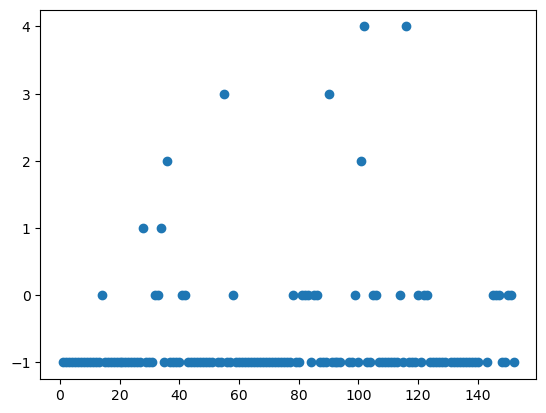

In [550]:
fig, ax = plt.subplots()
#ax.scatter(df2['siteid'], df2['cluster'])
#ax.scatter(df2['siteid'], df2['cluster_agc_ward'])
ax.scatter(df2['siteid'], df2['cluster_dbscan'])

#plt.savefig('testing.png', dpi=500)
#df2[['siteid', 'cluster']]

From the graphing above, I decided to continue with Agglomerative Clustering as the distribution between the clusters is more disperse compared to KMeans. For DBSCAN, the algorithm had trouble picking up underlying numbers and as I tuned the hyperparamater, it either produced too many clusers (from 6 up to almost to 1 cluster per site) or too few clusters (2). For both agglomerative clustering and KMeans, I tuned the number of clusters from 2 to 3 to 4 and both methods produced the most interpretable results at 4 clusters. For low numbers, the split appeared largely to do with overall cycling counts, rather than the change in distribution based on the hours of the day.

In [562]:
df_cluster_counts_test.insert(0, 'siteid', df_cluster_col1, True)
df_cluster_counts_test.insert(1, 'average_hour_count', df_cluster_col2, True)
df_cluster_counts_test['cluster'] = kmeans
df_cluster_counts_test['cluster_agc_ward'] = agc
df_cluster_counts_test['cluster_dbscan'] = dbscan

In [563]:
df_cluster_counts_test

,siteid,average_hour_count,0,1,2,3,4,5,6,7,...,17,18,19,20,21,22,23,cluster,cluster_agc_ward,cluster_dbscan
0,1.0,6.356944,0.933333,0.370833,0.850000,0.708333,1.483333,1.783333,6.133333,11.179167,...,15.625000,10.279167,6.750000,4.216667,3.129167,3.208333,1.808333,0,1,-1
1,2.0,13.041146,1.195833,0.783333,0.545833,0.887500,1.508333,5.679167,10.629167,29.525000,...,24.462500,15.162500,10.608333,8.354167,5.995833,6.183333,1.987500,3,0,-1
2,3.0,11.833160,2.816667,1.145833,0.720833,0.629167,0.800000,4.050000,7.250000,20.308333,...,28.512500,20.112500,11.725000,7.762500,6.679167,6.991667,5.233333,3,0,-1
3,4.0,3.282118,0.200000,0.083333,0.329167,0.108333,1.087500,4.875000,2.375000,4.804167,...,5.158333,4.270833,3.404167,3.633333,1.358333,0.608333,0.308333,0,1,-1
4,5.0,3.328299,0.295833,0.304167,0.187500,0.200000,0.500000,0.812500,2.891667,4.120833,...,6.900000,5.487500,3.812500,4.095833,1.825000,1.366667,0.629167,0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,148.0,6.594444,0.404167,0.087500,0.145833,0.041667,0.004167,0.358333,1.375000,9.887500,...,18.912500,18.058333,10.366667,3.858333,1.312500,0.691667,0.658333,0,1,-1
141,149.0,6.459722,1.225000,1.212500,0.991667,0.625000,0.520833,1.250000,3.616667,9.829167,...,16.733333,13.158333,7.445833,4.954167,3.687500,2.425000,2.158333,0,1,-1
142,150.0,2.292361,0.166667,0.025000,0.066667,0.000000,0.004167,0.270833,0.670833,3.420833,...,6.275000,4.912500,3.108333,1.237500,0.454167,0.391667,0.150000,0,1,0
143,151.0,3.112153,0.304167,0.145833,0.158333,0.033333,0.025000,0.225000,0.487500,1.766667,...,8.720833,6.200000,3.362500,2.095833,1.479167,0.954167,0.408333,0,1,0


In [565]:
df_varun = pd.DataFrame()
varun_dictionary = {}
for num in range(0, 24):
    varun_dictionary[num] = []
    a = df_cluster_counts_test.groupby('cluster')[str(num)].mean()
    for val in a:
        varun_dictionary[num].append(val)

    b = df_cluster_counts_test.groupby('cluster_agc_ward')[str(num)].mean()
    for val in b:
        varun_dictionary[num].append(val)



In [566]:
for key in varun_dictionary:
    print(f'Here is the differences between the values for hour {key}')
    print(f'Cluster 0: {varun_dictionary[key][4]}')
    print(f'Cluster 1: {varun_dictionary[key][5]}')
    print(f'Cluster 2: {varun_dictionary[key][6]}')
    print(f'Cluster 3: {varun_dictionary[key][7]}')



Here is the differences between the values for hour 0
Cluster 0: 1.3708333333333333
Cluster 1: 0.4820987654320988
Cluster 2: 13.585416666666667
Cluster 3: 4.064583333333333
Here is the differences between the values for hour 1
Cluster 0: 0.8742283950617284
Cluster 1: 0.32523148148148145
Cluster 2: 8.439583333333333
Cluster 3: 2.68125
Here is the differences between the values for hour 2
Cluster 0: 0.5763888888888888
Cluster 1: 0.24895833333333334
Cluster 2: 4.8125
Cluster 3: 1.5734375
Here is the differences between the values for hour 3
Cluster 0: 0.611574074074074
Cluster 1: 0.2127314814814815
Cluster 2: 3.3125
Cluster 3: 1.0151041666666667
Here is the differences between the values for hour 4
Cluster 0: 1.5646604938271607
Cluster 1: 0.4018132716049383
Cluster 2: 3.433333333333333
Cluster 3: 1.6442708333333333
Here is the differences between the values for hour 5
Cluster 0: 4.5317901234567906
Cluster 1: 1.1884645061728394
Cluster 2: 9.0875
Cluster 3: 6.021354166666667
Here is the dif

The code above was created to understand the change in hourly counts per cluster to better understand the behavior the ac algorithm is picking up on.

Inferences from above:
Cluster 0 is higher than 1 and also has a clear commuting pattern
Cluster 1 is low but shows a clear commuting pattern
Cluster 2 is always the highest
Cluster 3 is higher than 0 and has a clear commuting pattern


Below is the code for the creation of the csv file that will be used for the application

In [568]:
site_location_dict = {}

for index, value in sites[['siteid','longitude', 'latitude']].iterrows():
    site_location_dict[value[0]] = [value[1], value[2]]

/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/1571555356.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  site_location_dict[value[0]] = [value[1], value[2]]


In [569]:
df2['average_hour_count'] = round(df2['average_hour_count'], 2)

In [570]:
sites_updated = df2[['siteid', 'cluster', 'cluster_agc_ward', 'average_hour_count']].copy()

In [571]:
for index, val in sites_updated.iterrows():
    if val.siteid in site_location_dict:
        sites_updated.loc[index, 'longitude'] = site_location_dict[val.siteid][0]
        sites_updated.loc[index, 'latitude'] = site_location_dict[val.siteid][1]

In [572]:
for index, val in sites_updated.iterrows():
    if val.cluster == 0:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 255
    elif val.cluster == 1:
        sites_updated.loc[index, 'color1'] = 255
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 20
    elif val.cluster == 2:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 255
        sites_updated.loc[index, 'color3'] = 20
    else:
        sites_updated.loc[index, 'color1'] = 52
        sites_updated.loc[index, 'color2'] = 52
        sites_updated.loc[index, 'color3'] = 52

for index, val in sites_updated.iterrows():
    if val.cluster_agc_ward == 0:
        sites_updated.loc[index, 'color4'] = 20
        sites_updated.loc[index, 'color5'] = 20
        sites_updated.loc[index, 'color6'] = 255
    elif val.cluster_agc_ward == 1:
        sites_updated.loc[index, 'color4'] = 255
        sites_updated.loc[index, 'color5'] = 20
        sites_updated.loc[index, 'color6'] = 20
    elif val.cluster_agc_ward == 2:
        sites_updated.loc[index, 'color4'] = 20
        sites_updated.loc[index, 'color5'] = 255
        sites_updated.loc[index, 'color6'] = 20
    else:
        sites_updated.loc[index, 'color4'] = 52
        sites_updated.loc[index, 'color5'] = 52
        sites_updated.loc[index, 'color6'] = 52

Below is the explicit output to csv that will be used for the application

In [573]:
sites_updated.to_csv('sites_cluster.csv', index=False)